In [1]:
# Represent the graph

In [2]:
# https://www.desmos.com/calculator

# Standardization(Machine Learning)

<!-- Standardization ek feature scaling technique hai jisme hum data ko is tarah transform karte hain ki:

        Mean (average) = 0
        Standard deviation = 1
        
        Isko Z-score normalization bhi bolte hain. -->

In [4]:
# Standardization ek feature scaling technique hai jisme hum data ko is tarah transform karte hain ki:

        # Mean (average) = 0
        # Standard deviation = 1
        
        # Isko Z-score normalization bhi bolte hain.

In [5]:
# Maan lo tumhare paas 2 features hain:

| Student | Height (cm) | Salary (₹) |
| ------- | ----------- | ---------- |
| A       | 170         | 50,000     |
| B       | 180         | 80,000     |
| C       | 160         | 30,000     |


In [6]:
# Problem:

#     Height ka range ≈ 160–180
#     Salary ka range ≈ 30k–80k
    
#      ML model confuse ho jayega kyunki salary values bahut bade scale par hain.
    
#      Solution = Standardization

In [7]:
# After standardization:

| Student | Height | Salary |
| ------- | ------ | ------ |
| A       | ~0     | ~0     |
| B       | +1     | +1     |
| C       | -1     | -1     |


In [8]:
# Ab dono features same scale par aa gaye → model better learn karega


# Why Standardization important hai?

In [10]:
# Features ko equal importance dena

#         Agar scaling nahi karoge → bade numbers dominate karenge
# Faster training

#         Gradient descent algorithms jaldi converge karte hain

# Better performance

# Especially in:

#         Linear Regression
#         Logistic Regression
#         Neural Networks

In [11]:
# Kab use karte hain? (Important)

#   Standardization use karo jab:

#  1. Data normal distribution ke paas ho
#      Gaussian distribution ho → best kaam karta hai

#  2. Distance-based algorithms use ho
#         KNN
#         K-means
#         SVM
#  3. Gradient-based algorithms

#         Linear Regression
#         Logistic Regression
#         Neural Networks

| Feature  | Standardization | Normalization |
| -------- | --------------- | ------------- |
| Range    | Fixed nahi      | 0–1           |
| Mean     | 0               | change hota   |
| Use case | Gaussian data   | bounded data  |


In [12]:
# Standardization = data ko normalize nahi, center + scale karna
#          Mean = 0, Std = 1
#          Use when:

# ML model distance/gradient use karta ho
# Data ka scale different ho

In [13]:
import pandas as pd

data = pd.DataFrame({
    "size": [1000, 1500, 1800, 2000, 2200, 2500, 3000, 3200],
    "bedrooms": [2, 3, 3, 4, 4, 5, 5, 6],
    "age": [10, 15, 7, 5, 3, 2, 1, 12],
    "distance_from_city": [15, 10, 8, 7, 5, 6, 4, 3],
    "price": [50, 65, 80, 90, 100, 120, 150, 170]  # target
})

In [14]:
data

,size,bedrooms,age,distance_from_city,price
0,1000,2,10,15,50
1,1500,3,15,10,65
2,1800,3,7,8,80
3,2000,4,5,7,90
4,2200,4,3,5,100
5,2500,5,2,6,120
6,3000,5,1,4,150
7,3200,6,12,3,170


In [15]:
# Size ka range sabse bada → model usko importance dega
#     Bedrooms/age ignore ho sakte hain
    
#     Agar tum Linear Regression / KNN / SVM use kar rahe ho → result biased hoga 

In [16]:
# Solution → Standardization

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
# input features (target ko hata diya)
X = data.drop("price", axis=1)

In [19]:
X

,size,bedrooms,age,distance_from_city
0,1000,2,10,15
1,1500,3,15,10
2,1800,3,7,8
3,2000,4,5,7
4,2200,4,3,5
5,2500,5,2,6
6,3000,5,1,4
7,3200,6,12,3


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled

array([[-1.65988202, -1.63299316,  0.66087632,  2.15464895],
       [-0.93819419, -0.81649658,  1.71827844,  0.76455285],
       [-0.50518149, -0.81649658,  0.02643505,  0.20851441],
       [-0.21650635,  0.        , -0.39652579, -0.0695048 ],
       [ 0.07216878,  0.        , -0.81948664, -0.62554324],
       [ 0.50518149,  0.81649658, -1.03096706, -0.34752402],
       [ 1.22686932,  0.81649658, -1.24244748, -0.90356246],
       [ 1.51554446,  1.63299316,  1.08383717, -1.18158168]])

In [22]:
# back to dataframe
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [23]:
scaled_df

,size,bedrooms,age,distance_from_city
0,-1.659882,-1.632993,0.660876,2.154649
1,-0.938194,-0.816497,1.718278,0.764553
2,-0.505181,-0.816497,0.026435,0.208514
3,-0.216506,0.000000,-0.396526,-0.069505
4,0.072169,0.000000,-0.819487,-0.625543
5,0.505181,0.816497,-1.030967,-0.347524
6,1.226869,0.816497,-1.242447,-0.903562
7,1.515544,1.632993,1.083837,-1.181582


In [24]:
# Key observations:

#     Mean ≈ 0
#     Values ≈ -2 se +2 ke beech
#     Sab features equal scale pe

In [25]:
data

,size,bedrooms,age,distance_from_city,price
0,1000,2,10,15,50
1,1500,3,15,10,65
2,1800,3,7,8,80
3,2000,4,5,7,90
4,2200,4,3,5,100
5,2500,5,2,6,120
6,3000,5,1,4,150
7,3200,6,12,3,170


In [26]:
scaled_df

,size,bedrooms,age,distance_from_city
0,-1.659882,-1.632993,0.660876,2.154649
1,-0.938194,-0.816497,1.718278,0.764553
2,-0.505181,-0.816497,0.026435,0.208514
3,-0.216506,0.000000,-0.396526,-0.069505
4,0.072169,0.000000,-0.819487,-0.625543
5,0.505181,0.816497,-1.030967,-0.347524
6,1.226869,0.816497,-1.242447,-0.903562
7,1.515544,1.632993,1.083837,-1.181582


In [28]:
scaled_df['price'] = data['price']

In [29]:
scaled_df

,size,bedrooms,age,distance_from_city,price
0,-1.659882,-1.632993,0.660876,2.154649,50
1,-0.938194,-0.816497,1.718278,0.764553,65
2,-0.505181,-0.816497,0.026435,0.208514,80
3,-0.216506,0.000000,-0.396526,-0.069505,90
4,0.072169,0.000000,-0.819487,-0.625543,100
5,0.505181,0.816497,-1.030967,-0.347524,120
6,1.226869,0.816497,-1.242447,-0.903562,150
7,1.515544,1.632993,1.083837,-1.181582,170


In [30]:
# Raw Data
#    ↓
# Train-Test Split
#    ↓
# Standardization (ONLY on X)
#    ↓
# Model Training
#    ↓
# Prediction

In [31]:
scaled_df.describe()

,size,bedrooms,age,distance_from_city,price
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.000000,0.000000,0.000000,0.000000,103.125000
std,1.069045,1.069045,1.069045,1.069045,41.312183
min,-1.659882,-1.632993,-1.242447,-1.181582,50.000000
25%,-0.613435,-0.816497,-0.872357,-0.695048,76.250000
50%,-0.072169,0.000000,-0.185045,-0.208514,95.000000
75%,0.685603,0.816497,0.766617,0.347524,127.500000
max,1.515544,1.632993,1.718278,2.154649,170.000000


| Step      | Kya karna hai          |
| --------- | ---------------------- |
| ❌ Wrong   | full data pe fit       |
| ✅ Correct | train pe fit           |
| ✅ Correct | test pe sirf transform |


In [32]:
# Scaling FULL dataset pe ek sath nahi karni chahiye

#  Scaling sirf training data pe “fit” hoti hai

#  Test data pe sirf “transform” hota hai

| Step          | Kya hota hai        |
| ------------- | ------------------- |
| Training data | **fit + transform** |
| Test data     | **sirf transform**  |


In [33]:
import pandas as pd

data = pd.DataFrame({
    "size": [1000,1200,1500,1800,2000,2200,2500,2700,3000,3200,3500,3700,4000,4200,4500],
    "bedrooms": [2,2,3,3,4,4,5,5,5,6,6,6,7,7,8],
    "age": [15,12,10,8,7,6,5,4,3,2,2,3,4,5,6],
    "distance": [20,18,15,12,10,9,8,7,6,5,4,6,7,8,9],
    "price": [40,50,65,80,90,100,120,130,150,160,180,190,210,220,250]
})

In [34]:
data

,size,bedrooms,age,distance,price
0,1000,2,15,20,40
1,1200,2,12,18,50
2,1500,3,10,15,65
3,1800,3,8,12,80
4,2000,4,7,10,90
5,2200,4,6,9,100
6,2500,5,5,8,120
7,2700,5,4,7,130
8,3000,5,3,6,150
9,3200,6,2,5,160


In [35]:
# size dominate karega
# model sochega → sirf size important hai

In [36]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# # ❌ WRONG
# scaled_all = scaler.fit_transform(data)

In [37]:
# price bhi scale ho gaya (galat)
# train + test mix ho gaya
# leakage ❌

# Correct Approach

In [38]:
X = data.drop("price", axis=1)
y = data["price"]

In [39]:
X

,size,bedrooms,age,distance
0,1000,2,15,20
1,1200,2,12,18
2,1500,3,10,15
3,1800,3,8,12
4,2000,4,7,10
5,2200,4,6,9
6,2500,5,5,8
7,2700,5,4,7
8,3000,5,3,6
9,3200,6,2,5


In [40]:
y

0      40
1      50
2      65
3      80
4      90
5     100
6     120
7     130
8     150
9     160
10    180
11    190
12    210
13    220
14    250
Name: price, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [43]:
X_train

,size,bedrooms,age,distance
4,2000,4,7,10
5,2200,4,6,9
10,3500,6,2,4
13,4200,7,5,8
0,1000,2,15,20
1,1200,2,12,18
12,4000,7,4,7
3,1800,3,8,12
11,3700,6,3,6
2,1500,3,10,15


In [44]:
X_test

,size,bedrooms,age,distance
6,2500,5,5,8
8,3000,5,3,6
14,4500,8,6,9


In [45]:
y_train

4      90
5     100
10    180
13    220
0      40
1      50
12    210
3      80
11    190
2      65
9     160
7     130
Name: price, dtype: int64

In [46]:
y_test

6     120
8     150
14    250
Name: price, dtype: int64

# Scaling

In [47]:
scaler = StandardScaler()

#  Fit ONLY on training
X_train_scaled = scaler.fit_transform(X_train)

# Transform test using same scaler
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled

array([[-0.54402685, -0.33258004,  0.12734291, -0.01686698],
       [-0.35750336, -0.33258004, -0.12734291, -0.21927074],
       [ 0.85489933,  0.80769437, -1.14608617, -1.23128956],
       [ 1.50773154,  1.37783158, -0.38202872, -0.42167451],
       [-1.4766443 , -1.47285445,  2.16482944,  2.00717064],
       [-1.29012081, -1.47285445,  1.40077199,  1.60236312],
       [ 1.32120805,  1.37783158, -0.63671454, -0.62407827],
       [-0.73055034, -0.90271724,  0.38202872,  0.38794054],
       [ 1.04142282,  0.80769437, -0.89140036, -0.82648203],
       [-1.01033557, -0.90271724,  0.89140036,  0.99515183],
       [ 0.57511409,  0.80769437, -1.14608617, -1.02888579],
       [ 0.10880537,  0.23755717, -0.63671454, -0.62407827]])

In [49]:
X_test_scaled

array([[-0.07771812,  0.23755717, -0.38202872, -0.42167451],
       [ 0.3885906 ,  0.23755717, -0.89140036, -0.82648203],
       [ 1.78751678,  1.94796879, -0.12734291, -0.21927074]])

In [50]:
# scaler ne training data se seekha:

# mean (average)
# std deviation

In [51]:
# convert back to dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [52]:
X_train_scaled_df

,size,bedrooms,age,distance
0,-0.544027,-0.332580,0.127343,-0.016867
1,-0.357503,-0.332580,-0.127343,-0.219271
2,0.854899,0.807694,-1.146086,-1.231290
3,1.507732,1.377832,-0.382029,-0.421675
4,-1.476644,-1.472854,2.164829,2.007171
5,-1.290121,-1.472854,1.400772,1.602363
6,1.321208,1.377832,-0.636715,-0.624078
7,-0.730550,-0.902717,0.382029,0.387941
8,1.041423,0.807694,-0.891400,-0.826482
9,-1.010336,-0.902717,0.891400,0.995152


In [53]:
X_test_scaled_df

,size,bedrooms,age,distance
0,-0.077718,0.237557,-0.382029,-0.421675
1,0.388591,0.237557,-0.891400,-0.826482
2,1.787517,1.947969,-0.127343,-0.219271


In [54]:
# target add karo
X_train_scaled_df["price"] = y_train.values
X_test_scaled_df["price"] = y_test.values

In [55]:
X_train_scaled_df

,size,bedrooms,age,distance,price
0,-0.544027,-0.332580,0.127343,-0.016867,90
1,-0.357503,-0.332580,-0.127343,-0.219271,100
2,0.854899,0.807694,-1.146086,-1.231290,180
3,1.507732,1.377832,-0.382029,-0.421675,220
4,-1.476644,-1.472854,2.164829,2.007171,40
5,-1.290121,-1.472854,1.400772,1.602363,50
6,1.321208,1.377832,-0.636715,-0.624078,210
7,-0.730550,-0.902717,0.382029,0.387941,80
8,1.041423,0.807694,-0.891400,-0.826482,190
9,-1.010336,-0.902717,0.891400,0.995152,65


In [56]:
X_test_scaled_df

,size,bedrooms,age,distance,price
0,-0.077718,0.237557,-0.382029,-0.421675,120
1,0.388591,0.237557,-0.891400,-0.826482,150
2,1.787517,1.947969,-0.127343,-0.219271,250


In [57]:
# Raw Data
#    ↓
# Split (Train/Test)
#    ↓
# Fit scaler on Train
#    ↓
# Transform Train + Test
#    ↓
# Model Train
#    ↓
# Prediction

In [58]:
# ❌ Galat:
# full dataset pe scaling
# test data ka use → leakage

# ✅ Sahi:
# train pe fit
# test pe transform

In [59]:
# "Scaler ko sirf training data se seekhna chahiye"

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Done")

Done


In [191]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\Python\EDA and Feature Engineering\Dataset\Social_Network_Ads.csv")

In [192]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [193]:
df = df.iloc[:,2:]

In [194]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [195]:
df.sample(5)

,Age,EstimatedSalary,Purchased
31,27,137000,1
340,53,104000,1
103,33,149000,1
128,30,17000,0
138,28,59000,0


# Revoummenended Train test split

In [196]:
from sklearn.model_selection import train_test_split

In [197]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),
                                                 df['Purchased'],
                                                 train_size=0.3,
                                                 random_state=0
                                                )

In [198]:
X_train

,Age,EstimatedSalary
266,40,75000
36,33,28000
382,44,139000
58,22,18000
41,33,51000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [199]:
X_test

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000
...,...,...
80,30,80000
258,58,95000
11,26,52000
298,45,79000


In [200]:
y_train

266    0
36     0
382    1
58     0
41     0
      ..
323    1
192    0
117    0
47     0
172    0
Name: Purchased, Length: 120, dtype: int64

In [201]:
y_test

132    0
309    0
341    0
196    0
246    0
      ..
80     0
258    1
11     0
298    0
86     0
Name: Purchased, Length: 280, dtype: int64

# Standard Scaler

In [202]:
from sklearn.preprocessing import StandardScaler

In [203]:
scaler  = StandardScaler()

In [204]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [205]:
X_train.shape

(120, 2)

In [206]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [207]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [208]:
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# or 

# scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# both are equal

In [209]:
X_train_scaled

array([[ 0.28180897,  0.23010328],
       [-0.41035341, -1.13598356],
       [ 0.67733032,  2.09030664],
       [-1.49803714, -1.42664034],
       [-0.41035341, -0.46747298],
       [ 0.57844998,  1.91591257],
       [-1.30027646, -1.01972085],
       [ 0.875091  , -1.31037763],
       [-0.21259273, -0.35121027],
       [ 1.66613372,  1.07300793],
       [ 1.07285168,  1.50899309],
       [-0.21259273, -0.40934162],
       [-0.01483205,  2.23563503],
       [-1.3991568 , -0.03148782],
       [-0.01483205,  2.03217528],
       [-0.60811409, -0.26401324],
       [-0.41035341, -0.75812975],
       [ 0.77621066, -1.31037763],
       [-0.70699443, -1.51383737],
       [-1.79467816, -1.39757466],
       [ 1.17173202,  0.2010376 ],
       [ 0.18292863,  1.59619012],
       [-0.21259273,  0.17197193],
       [ 0.18292863,  0.11384057],
       [-1.30027646, -1.28131195],
       [ 0.38068931,  0.14290625],
       [-0.80587477,  0.4626287 ],
       [ 1.66613372, -1.19411492],
       [-0.21259273,

In [210]:
scaler.mean_

array([3.71500000e+01, 6.70833333e+04])

In [211]:
X_train_scaled =  pd.DataFrame(X_train_scaled,columns=X_train.columns)

In [212]:
X_train_scaled.shape

(120, 2)

In [213]:
X_test_scaled.shape

(280, 2)

In [214]:
X_test_scaled =  pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [215]:
X_test_scaled

,Age,EstimatedSalary
0,-0.706994,0.578891
1,0.084048,-0.496539
2,-0.212593,0.230103
3,-0.706994,0.346366
4,-0.212593,-0.496539
...,...,...
275,-0.706994,0.375432
276,2.061655,0.811417
277,-1.102516,-0.438407
278,0.776211,0.346366


In [216]:
X_train_scaled.describe()

,Age,EstimatedSalary
count,1.200000e+02,1.200000e+02
mean,1.480297e-16,1.258253e-16
std,1.004193e+00,1.004193e+00
min,-1.893558e+00,-1.513837e+00
25%,-7.317145e-01,-7.726626e-01
50%,-1.483205e-02,-8.961917e-02
75%,4.795696e-01,4.771615e-01
max,2.259416e+00,2.410029e+00


In [217]:
X_test_scaled.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,0.071335,0.110415
std,1.051152,0.985317
min,-1.893558,-1.513837
25%,-0.731715,-0.649133
50%,-0.014832,0.113841
75%,0.875091,0.607957
max,2.259416,2.410029


In [218]:
np.round(X_train_scaled.describe())

,Age,EstimatedSalary
count,120.0,120.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,-0.0
75%,0.0,0.0
max,2.0,2.0


In [219]:
np.round(X_train.describe())

,Age,EstimatedSalary
count,120.0,120.0
mean,37.0,67083.0
std,10.0,34549.0
min,18.0,15000.0
25%,30.0,40500.0
50%,37.0,64000.0
75%,42.0,83500.0
max,60.0,150000.0


# Effect of scalling

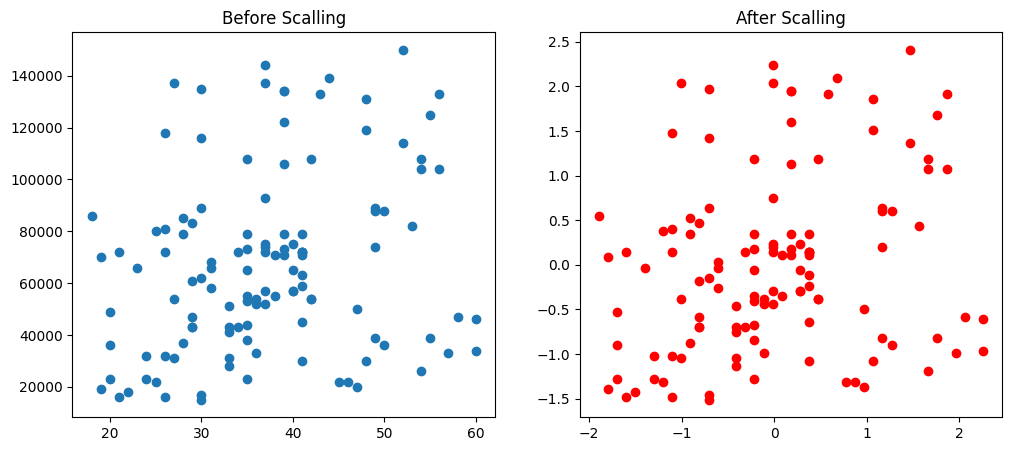

In [220]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scalling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After Scalling')
plt.show()

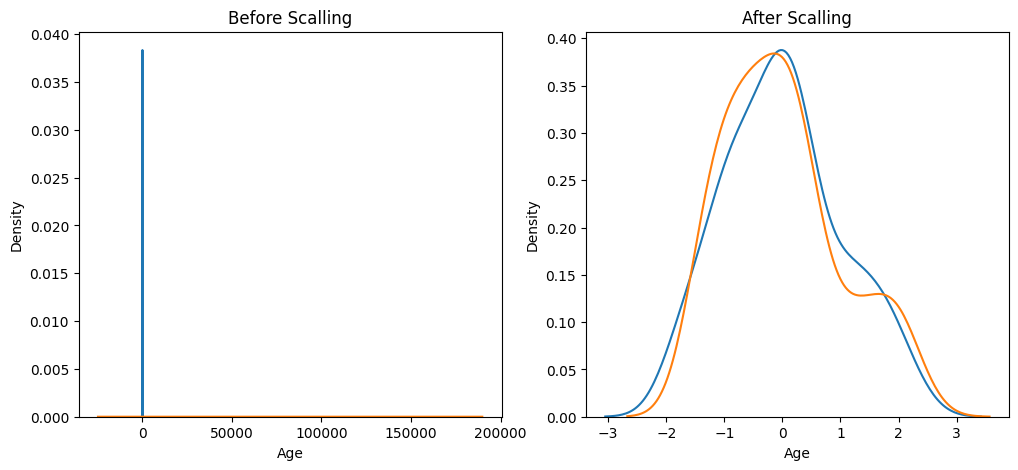

In [221]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
# before scalling
ax1.set_title('Before Scalling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#after Scalling

ax2.set_title('After Scalling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

plt.show()

# Why scalling important

In [222]:
from sklearn.linear_model import LogisticRegression

In [223]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [224]:
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [225]:
lr_scaled.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [226]:
y_pred = lr.predict(X_test)

In [227]:
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [228]:
from sklearn.metrics import accuracy_score

In [229]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.7964285714285714
Scaled 0.7821428571428571


In [230]:
print(lr.coef_)
print(lr_scaled.coef_)

[[2.90798394e-01 4.18389936e-05]]
[[2.24392825 1.12230107]]


In [231]:
# Scaling improves learning quality, not necessarily accuracy

In [232]:
# Step 1
X = df.drop('Purchased', axis=1)
y = df['Purchased']

# Step 2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Step 3
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # ONLY transform

In [233]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [234]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)